In [1]:
import flappy_bird_env  # noqa
import numpy as np
import matplotlib.pyplot as plt
import cv2
import gymnasium as gym

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
def create_mask(observation):
    """
    Create a semantic mask from RGB observation.
    
    Bird pixels = -1, Background pixels = 0, Pipe pixels = +1
    
    Args:
        observation: RGB image array of shape (H, W, 3) with values 0-255
        
    Returns:
        Mask array of shape (H, W) with values -1, 0, or +1
    """
    # Convert RGB to HSV for better color segmentation
    hsv = cv2.cvtColor(observation.astype(np.uint8), cv2.COLOR_RGB2HSV)
    
    # Initialize mask as background (0)
    mask = np.zeros((observation.shape[0], observation.shape[1]), dtype=np.float32)
    
    # Identify bird pixels (yellow/orange)
    # Yellow/Orange in HSV: H ~10-30, S ~100-255, V ~100-255
    bird_lower = np.array([10, 100, 100])
    bird_upper = np.array([30, 255, 255])
    bird_mask = cv2.inRange(hsv, bird_lower, bird_upper)
    mask[bird_mask > 0] = -1.0
    
    # Identify pipe pixels (green)
    # Green in HSV: H ~40-80, S ~50-255, V ~50-255
    pipe_lower = np.array([40, 50, 50])
    pipe_upper = np.array([80, 255, 255])
    pipe_mask = cv2.inRange(hsv, pipe_lower, pipe_upper)
    mask[pipe_mask > 0] = 1.0
    
    # Background is already 0 (default)
    
    return mask

print("✓ Mask generation function created")

✓ Mask generation function created


In [3]:
# Create environment and capture frames
env = gym.make("FlappyBird-v0", render_mode="rgb_array")
observation, _ = env.reset()
observation = np.asarray(observation, dtype=np.uint8)

# Run a few steps to get interesting frames with bird and pipes
frames = []
for step in range(10):
    action = 1 if step % 5 == 0 else 0  # Flap occasionally
    observation, reward, terminated, truncated, _ = env.step(action)
    observation = np.asarray(observation, dtype=np.uint8)
    
    frames.append({
        'step': step,
        'rgb': observation.copy()
    })
    
    if terminated or truncated:
        observation, _ = env.reset()
        observation = np.asarray(observation, dtype=np.uint8)

env.close()

print(f"✓ Captured {len(frames)} frames")
print(f"Frame shape: {frames[0]['rgb'].shape}")

✓ Captured 10 frames
Frame shape: (800, 576, 3)


In [5]:
# Generate masks for all frames
for frame_data in frames:
    frame_data['mask'] = create_mask(frame_data['rgb'])
    frame_data['stats'] = {
        'bird_pixels': np.sum(frame_data['mask'] == -1),
        'background_pixels': np.sum(frame_data['mask'] == 0),
        'pipe_pixels': np.sum(frame_data['mask'] == 1),
        'total_pixels': frame_data['mask'].size
    }

print("✓ Masks generated for all frames")

✓ Masks generated for all frames


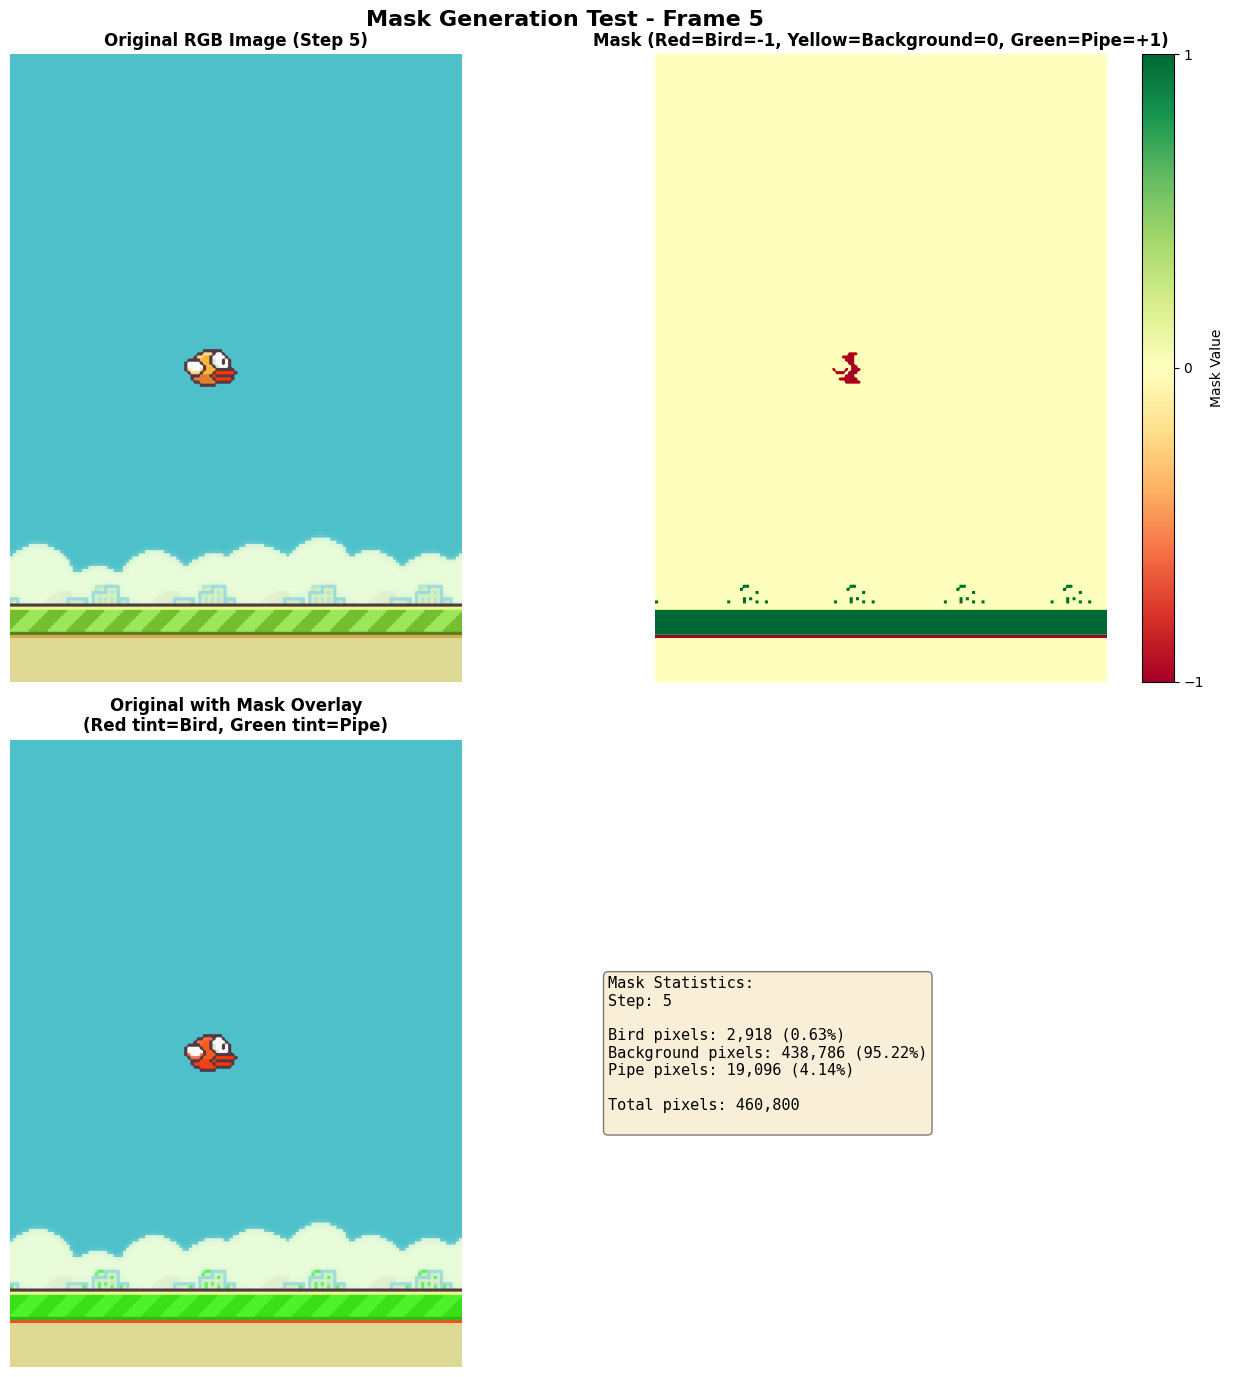

In [6]:
# Visualize a single frame in detail
frame_idx = 5  # Choose a frame
frame = frames[frame_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Original RGB image
axes[0, 0].imshow(frame['rgb'])
axes[0, 0].set_title(f"Original RGB Image (Step {frame['step']})", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Mask visualization (using custom colormap)
mask_display = axes[0, 1].imshow(frame['mask'], cmap='RdYlGn', vmin=-1, vmax=1)
axes[0, 1].set_title("Mask (Red=Bird=-1, Yellow=Background=0, Green=Pipe=+1)", 
                     fontsize=12, fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(mask_display, ax=axes[0, 1], ticks=[-1, 0, 1], 
             label='Mask Value')

# Overlay mask on original
overlay = frame['rgb'].copy().astype(np.float32) / 255.0
bird_overlay = frame['mask'] == -1
pipe_overlay = frame['mask'] == 1
overlay[bird_overlay] = overlay[bird_overlay] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5  # Red tint for bird
overlay[pipe_overlay] = overlay[pipe_overlay] * 0.5 + np.array([0.0, 1.0, 0.0]) * 0.5  # Green tint for pipe
axes[1, 0].imshow(overlay)
axes[1, 0].set_title("Original with Mask Overlay\n(Red tint=Bird, Green tint=Pipe)", 
                     fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Statistics
stats = frame['stats']
stats_text = f"""Mask Statistics:
Step: {frame['step']}

Bird pixels: {stats['bird_pixels']:,} ({stats['bird_pixels']/stats['total_pixels']*100:.2f}%)
Background pixels: {stats['background_pixels']:,} ({stats['background_pixels']/stats['total_pixels']*100:.2f}%)
Pipe pixels: {stats['pipe_pixels']:,} ({stats['pipe_pixels']/stats['total_pixels']*100:.2f}%)

Total pixels: {stats['total_pixels']:,}
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, 
                verticalalignment='center', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.suptitle(f"Mask Generation Test - Frame {frame_idx}", 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

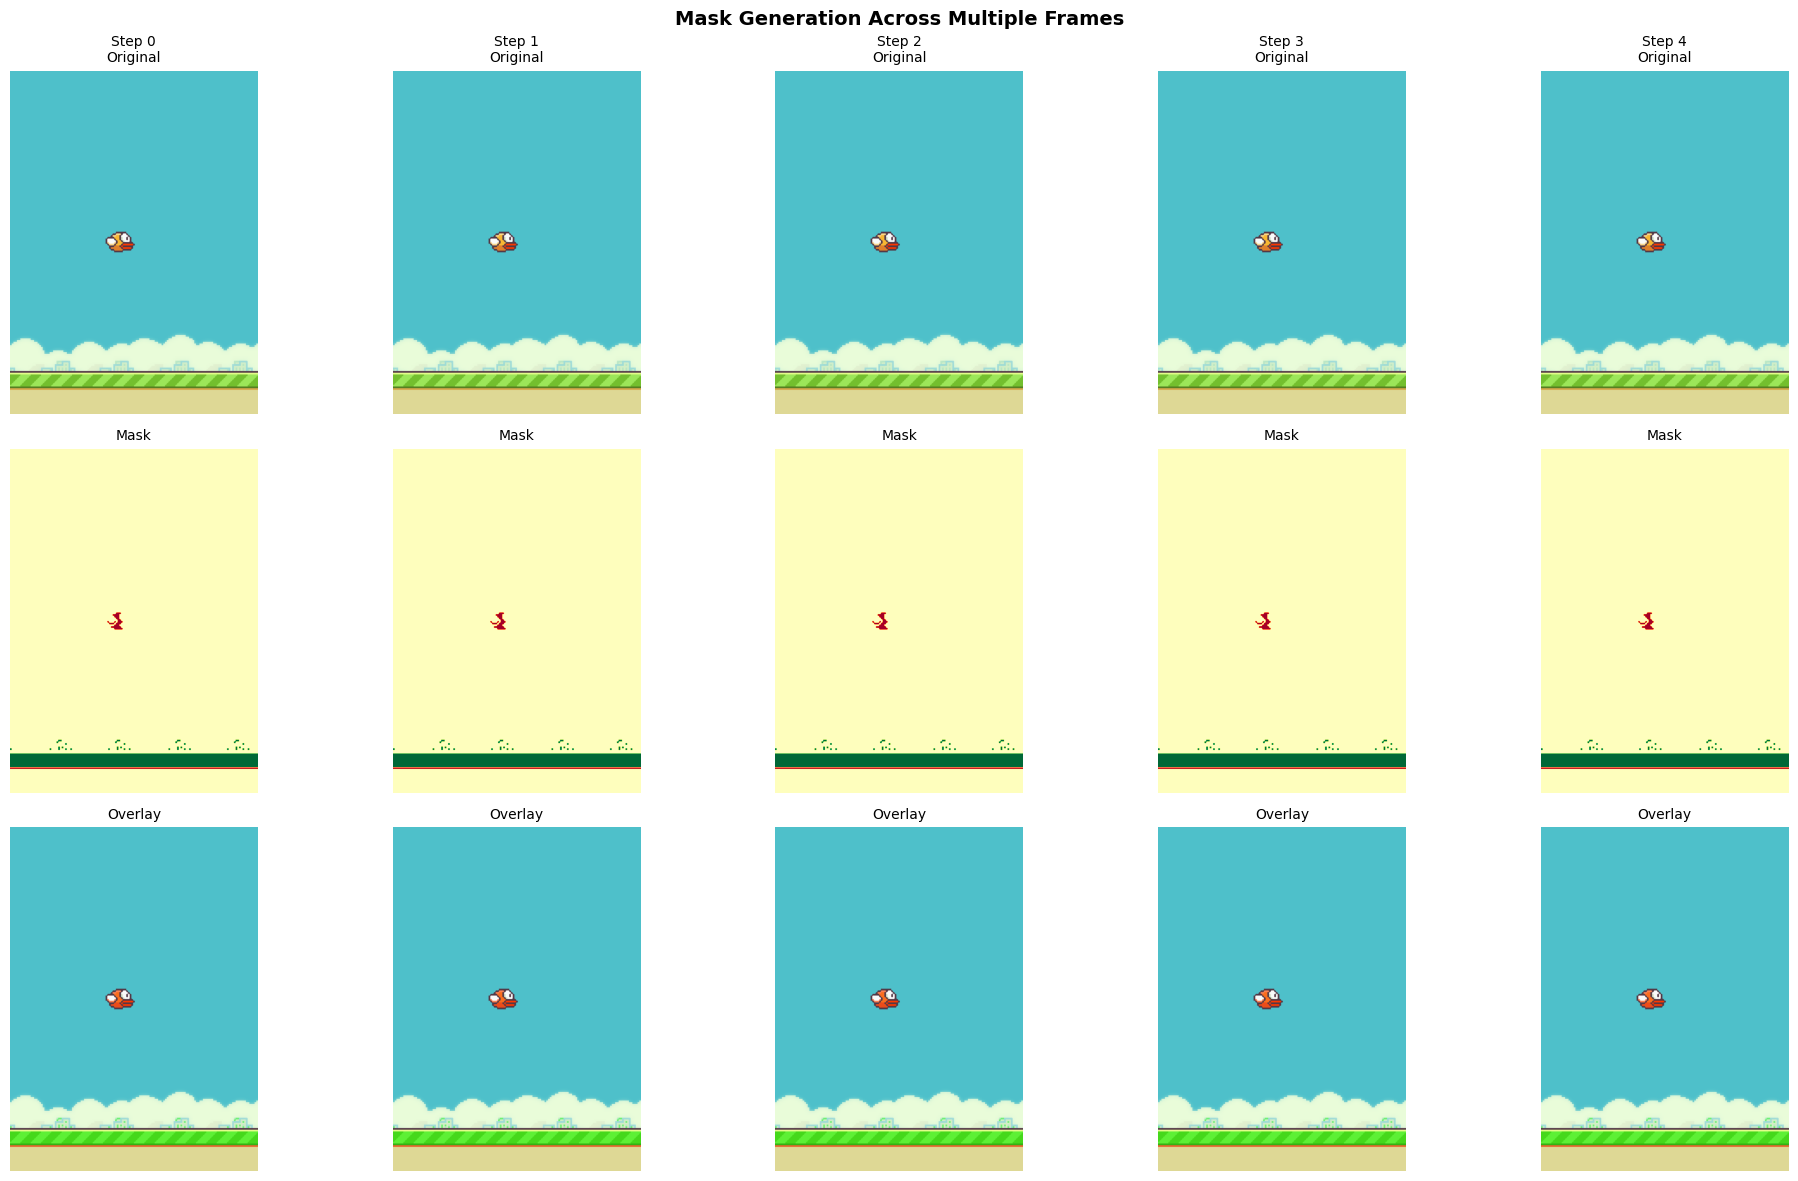

In [7]:
# Show masks across multiple frames
num_frames_to_show = min(5, len(frames))
fig, axes = plt.subplots(3, num_frames_to_show, figsize=(4*num_frames_to_show, 12))

for idx in range(num_frames_to_show):
    frame = frames[idx]
    
    # Original
    axes[0, idx].imshow(frame['rgb'])
    axes[0, idx].set_title(f"Step {frame['step']}\nOriginal", fontsize=10)
    axes[0, idx].axis('off')
    
    # Mask
    axes[1, idx].imshow(frame['mask'], cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1, idx].set_title(f"Mask", fontsize=10)
    axes[1, idx].axis('off')
    
    # Overlay
    overlay = frame['rgb'].copy().astype(np.float32) / 255.0
    bird_overlay = frame['mask'] == -1
    pipe_overlay = frame['mask'] == 1
    overlay[bird_overlay] = overlay[bird_overlay] * 0.6 + np.array([1.0, 0.0, 0.0]) * 0.4
    overlay[pipe_overlay] = overlay[pipe_overlay] * 0.6 + np.array([0.0, 1.0, 0.0]) * 0.4
    axes[2, idx].imshow(overlay)
    axes[2, idx].set_title(f"Overlay", fontsize=10)
    axes[2, idx].axis('off')

plt.suptitle("Mask Generation Across Multiple Frames", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Print statistics for all frames
print("=" * 80)
print("MASK STATISTICS ACROSS ALL FRAMES")
print("=" * 80)
print(f"{'Step':<8} {'Bird %':<12} {'Background %':<15} {'Pipe %':<12} {'Total Pixels':<15}")
print("-" * 80)

for frame in frames:
    stats = frame['stats']
    bird_pct = stats['bird_pixels'] / stats['total_pixels'] * 100
    bg_pct = stats['background_pixels'] / stats['total_pixels'] * 100
    pipe_pct = stats['pipe_pixels'] / stats['total_pixels'] * 100
    
    print(f"{frame['step']:<8} {bird_pct:<12.2f} {bg_pct:<15.2f} {pipe_pct:<12.2f} {stats['total_pixels']:<15,}")

print("=" * 80)

MASK STATISTICS ACROSS ALL FRAMES
Step     Bird %       Background %    Pipe %       Total Pixels   
--------------------------------------------------------------------------------
0        0.63         95.22           4.14         460,800        
1        0.63         95.22           4.14         460,800        
2        0.63         95.22           4.14         460,800        
3        0.63         95.22           4.14         460,800        
4        0.63         95.22           4.14         460,800        
5        0.63         95.22           4.14         460,800        
6        0.63         95.22           4.14         460,800        
7        0.63         95.22           4.14         460,800        
8        0.63         95.22           4.14         460,800        
9        0.63         95.22           4.14         460,800        


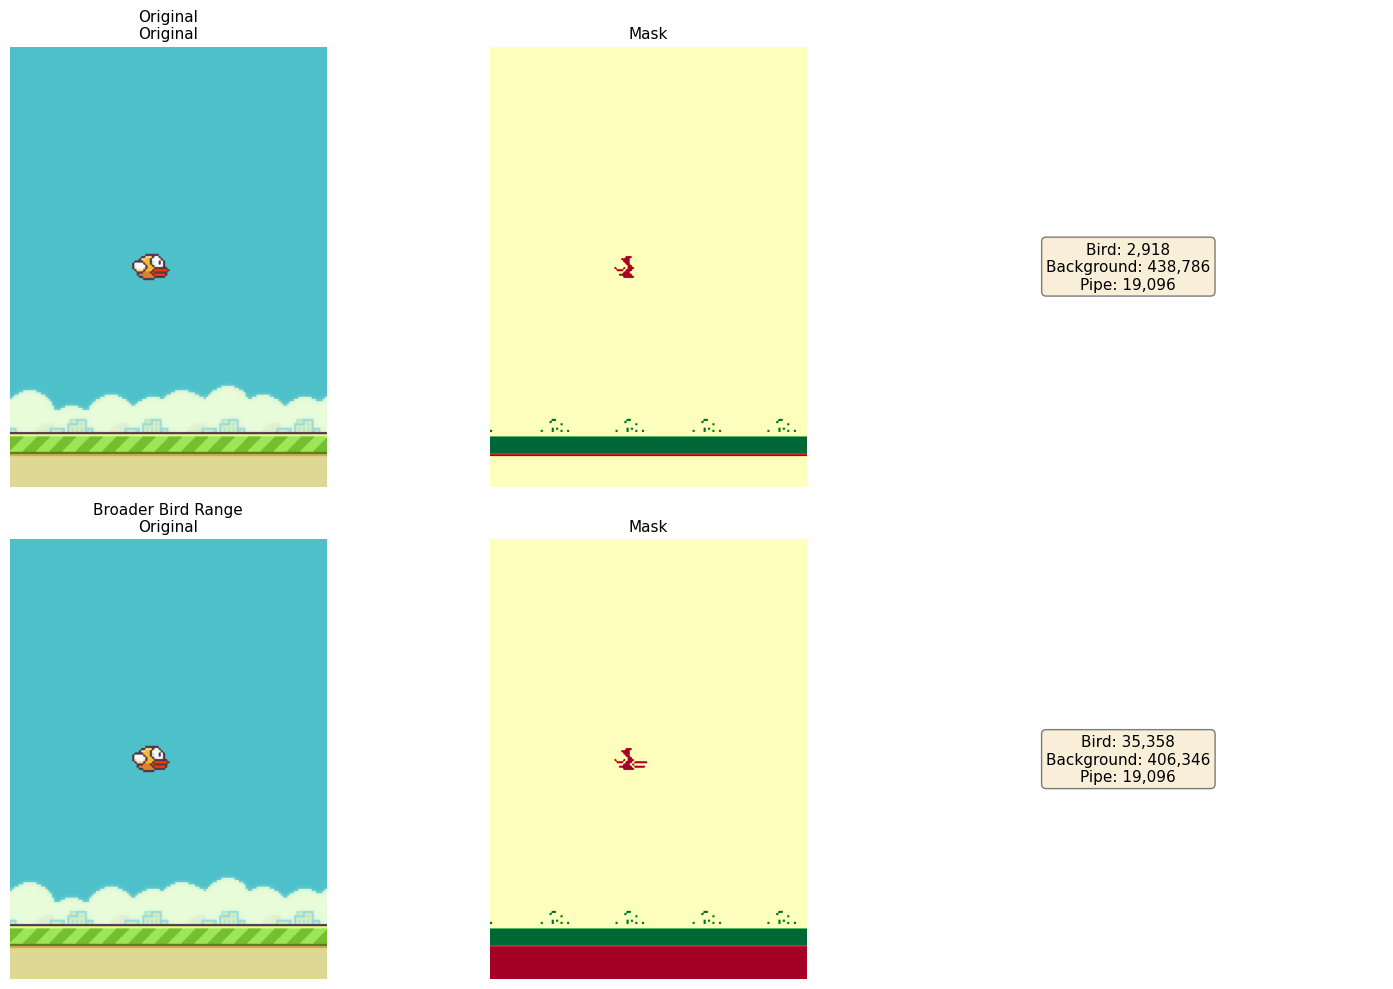

In [9]:
# Test different HSV ranges for better segmentation
def create_mask_with_params(observation, bird_h_range, bird_s_range, bird_v_range,
                            pipe_h_range, pipe_s_range, pipe_v_range):
    """Create mask with custom HSV ranges"""
    hsv = cv2.cvtColor(observation.astype(np.uint8), cv2.COLOR_RGB2HSV)
    mask = np.zeros((observation.shape[0], observation.shape[1]), dtype=np.float32)
    
    bird_lower = np.array([bird_h_range[0], bird_s_range[0], bird_v_range[0]])
    bird_upper = np.array([bird_h_range[1], bird_s_range[1], bird_v_range[1]])
    bird_mask = cv2.inRange(hsv, bird_lower, bird_upper)
    mask[bird_mask > 0] = -1.0
    
    pipe_lower = np.array([pipe_h_range[0], pipe_s_range[0], pipe_v_range[0]])
    pipe_upper = np.array([pipe_h_range[1], pipe_s_range[1], pipe_v_range[1]])
    pipe_mask = cv2.inRange(hsv, pipe_lower, pipe_upper)
    mask[pipe_mask > 0] = 1.0
    
    return mask

# Test frame
test_frame = frames[5]['rgb']

# Try different parameters
test_params = [
    {
        'name': 'Original',
        'bird_h': (10, 30), 'bird_s': (100, 255), 'bird_v': (100, 255),
        'pipe_h': (40, 80), 'pipe_s': (50, 255), 'pipe_v': (50, 255)
    },
    {
        'name': 'Broader Bird Range',
        'bird_h': (5, 35), 'bird_s': (80, 255), 'bird_v': (80, 255),
        'pipe_h': (40, 80), 'pipe_s': (50, 255), 'pipe_v': (50, 255)
    }
]

fig, axes = plt.subplots(len(test_params), 3, figsize=(15, 5*len(test_params)))

for i, params in enumerate(test_params):
    mask = create_mask_with_params(test_frame, 
                                    params['bird_h'], params['bird_s'], params['bird_v'],
                                    params['pipe_h'], params['pipe_s'], params['pipe_v'])
    
    axes[i, 0].imshow(test_frame)
    axes[i, 0].set_title(f"{params['name']}\nOriginal", fontsize=11)
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(mask, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[i, 1].set_title(f"Mask", fontsize=11)
    axes[i, 1].axis('off')
    
    # Stats
    stats_text = f"Bird: {np.sum(mask==-1):,}\nBackground: {np.sum(mask==0):,}\nPipe: {np.sum(mask==1):,}"
    axes[i, 2].text(0.5, 0.5, stats_text, fontsize=11, ha='center', va='center',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()